# Part 1: Imbalanced Baseline (No Balancing)
## Topic E: Transfer Learning for Medical Imaging
### Dataset: Chest X-Ray Pneumonia — https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia

**Goal of this notebook:** establish a *naive* baseline. We train two **from-scratch**
models on the dataset **as it ships** — using the original `train/val/test` folders
with **no class-balancing and no re-splitting**. The training set is imbalanced
(~2.7 : 1 PNEUMONIA : NORMAL) and the official validation set has only 16 images.

| # | Model | Mode | Balancing |
|---|---|---|---|
| 1 | SimpleCNN  | From Scratch | None |
| 2 | ResNet50   | From Scratch | None |

This sets up the problem: we expect decent *overall* accuracy but a **collapsed
NORMAL (minority) recall**. Part 2 fixes it with a proper split + balancing.

## 1. Setup & Imports

In [1]:
import os
import copy
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device   : {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device   : cuda
PyTorch version: 2.10.0+cu128


## 2. Load Dataset — Original Split, No Re-Balancing

We point `ImageFolder` at the **original** `train/`, `val/`, `test/` folders exactly
as Kaggle provides them. No merging, no stratified re-split, no sampler.

In [2]:
DATA_DIR = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'  # adjust if your path differs
IMG_SIZE = 224
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), train_transforms)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'),   eval_transforms)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'),  eval_transforms)

CLASS_NAMES = train_dataset.classes
BATCH_SIZE  = 32

# NOTE: plain shuffle, NO WeightedRandomSampler -> mini-batches keep the true imbalance
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print('Classes      :', CLASS_NAMES)
for name, ds in [('Train', train_dataset), ('Val', val_dataset), ('Test', test_dataset)]:
    print(f'{name:5s}: {len(ds):5d} images  dist={dict(Counter([y for _, y in ds.samples]))}')

Classes      : ['NORMAL', 'PNEUMONIA']
Train:  5216 images  dist={0: 1341, 1: 3875}
Val  :    16 images  dist={0: 8, 1: 8}
Test :   624 images  dist={0: 234, 1: 390}


## 3. Dataset Exploration & Visualization

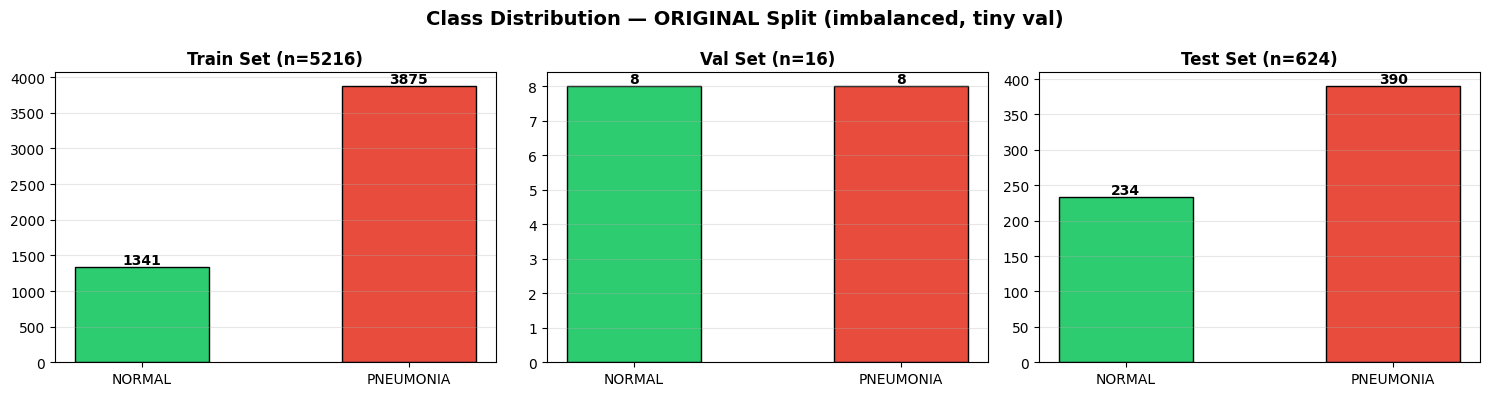

Train imbalance ratio: 2.89 : 1  (PNEUMONIA : NORMAL)
Official val set size: 16 images  <-- too small to monitor reliably


In [3]:
# Class distribution per split — exposes the imbalance and the tiny val set
split_counts = {name: Counter([y for _, y in ds.samples])
                for name, ds in [('Train', train_dataset), ('Val', val_dataset), ('Test', test_dataset)]}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#2ecc71', '#e74c3c']
for ax, (split, cnt) in zip(axes, split_counts.items()):
    vals = [cnt[i] for i in range(len(CLASS_NAMES))]
    bars = ax.bar(CLASS_NAMES, vals, color=colors, edgecolor='black', width=0.5)
    ax.set_title(f'{split} Set (n={sum(vals)})', fontweight='bold'); ax.grid(axis='y', alpha=.3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height(), str(v), ha='center', va='bottom', fontweight='bold')
plt.suptitle('Class Distribution — ORIGINAL Split (imbalanced, tiny val)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('p1_class_distribution.png', bbox_inches='tight', dpi=150); plt.show()

tr = split_counts['Train']
ratio = tr[CLASS_NAMES.index('PNEUMONIA')] / tr[CLASS_NAMES.index('NORMAL')]
print(f'Train imbalance ratio: {ratio:.2f} : 1  (PNEUMONIA : NORMAL)')
print(f'Official val set size: {len(val_dataset)} images  <-- too small to monitor reliably')

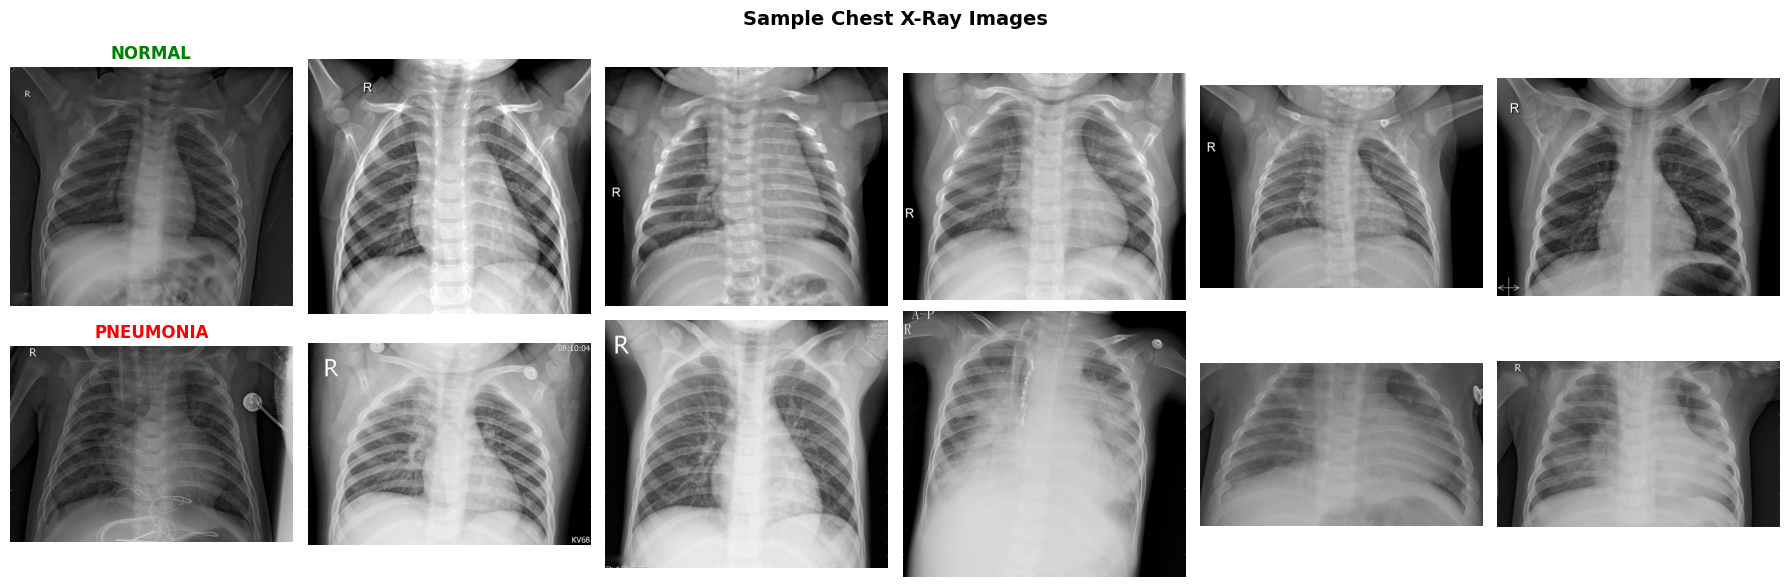

In [4]:
# Sample X-rays, one row per class
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for row, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(DATA_DIR, 'train', cls)
    for col, fname in enumerate(os.listdir(cls_dir)[:6]):
        img = Image.open(os.path.join(cls_dir, fname)).convert('RGB')
        axes[row, col].imshow(img, cmap='gray'); axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls, fontweight='bold', color='green' if row == 0 else 'red')
plt.suptitle('Sample Chest X-Ray Images', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('p1_sample_images.png', bbox_inches='tight', dpi=150); plt.show()

## 4. Models — SimpleCNN & ResNet50 (both from scratch)

In [5]:
# A small CNN built FROM SCRATCH (our own architecture, no ImageNet weights).
# 4 conv blocks -> global average pool -> dropout -> linear. ~0.4M params.
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(
            block(3,   32),   # 224 -> 112
            block(32,  64),   # 112 -> 56
            block(64,  128),  # 56  -> 28
            block(128, 128),  # 28  -> 14
        )
        self.pool       = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

In [6]:
def build_model(arch, num_classes=2):
    """FROM SCRATCH only (no pretrained weights) for this baseline notebook."""
    if arch == 'cnn':
        return SimpleCNN(num_classes)
    if arch == 'resnet50':
        m = models.resnet50(weights=None)               # weights=None -> random init
        m.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(m.fc.in_features, num_classes))
        return m
    raise ValueError(arch)

## 5. Training & Evaluation Functions

In [7]:
def train_model(model, train_loader, val_loader, num_epochs=20,
                lr=1e-3, patience=6, experiment_name='model',
                class_weights=None):
    """Train + validate. Returns (best_model, history).
    class_weights: optional tensor passed to CrossEntropyLoss (weighted loss).
    Best checkpoint = highest (val_acc + val_auc), ties broken by lower val_loss."""
    model     = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_auc': []}
    best_score, best_val_loss = 0.0, float('inf')
    best_weights = copy.deepcopy(model.state_dict())
    no_improve = 0

    print(f'\n{"="*60}\n  {experiment_name}\n{"="*60}')
    for epoch in range(num_epochs):
        start = time.time()
        # ---- train ----
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        bar = tqdm(train_loader, desc=f'Epoch [{epoch+1:02d}/{num_epochs}] Train', leave=False)
        for inputs, labels in bar:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item(); total += labels.size(0)
            bar.set_postfix(loss=f'{running_loss/total:.4f}', acc=f'{correct/total:.4f}')
        train_loss, train_acc = running_loss/total, correct/total

        # ---- val ----
        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        vp, vl = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs = model(inputs)
                loss    = criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)
                _, preds = outputs.max(1)
                correct += preds.eq(labels).sum().item(); total += labels.size(0)
                vp.extend(torch.softmax(outputs, 1)[:, 1].cpu().numpy())
                vl.extend(labels.cpu().numpy())
        val_loss, val_acc = running_loss/total, correct/total
        val_auc = roc_auc_score(vl, vp) if len(set(vl)) > 1 else 0.5
        scheduler.step(val_loss)

        for k, v in zip(history, [train_loss, val_loss, train_acc, val_acc, val_auc]):
            history[k].append(v)
        print(f'Epoch [{epoch+1:02d}/{num_epochs}]  '
              f'Train L {train_loss:.4f} A {train_acc:.4f} | '
              f'Val L {val_loss:.4f} A {val_acc:.4f} AUC {val_auc:.4f} | {time.time()-start:.1f}s')

        score = val_acc + val_auc
        if score > best_score or (score == best_score and val_loss < best_val_loss):
            best_score, best_val_loss = score, val_loss
            best_weights = copy.deepcopy(model.state_dict()); no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping at epoch {epoch+1}'); break

    model.load_state_dict(best_weights)
    return model, history

In [8]:
def evaluate_model(model, loader):
    """Return accuracy, AUC-ROC, sklearn report dict, confusion matrix, raw preds."""
    model.eval()
    preds, labels, probs = [], [], []
    with torch.no_grad():
        for inputs, lbls in loader:
            p = torch.softmax(model(inputs.to(DEVICE)), 1)
            preds.extend(p.argmax(1).cpu().numpy())
            labels.extend(lbls.numpy())
            probs.extend(p[:, 1].cpu().numpy())
    acc     = np.mean(np.array(preds) == np.array(labels))
    auc_roc = roc_auc_score(labels, probs) if len(set(labels)) > 1 else 0.5
    report  = classification_report(labels, preds, target_names=CLASS_NAMES, output_dict=True)
    return {'accuracy': acc, 'auc_roc': auc_roc, 'report': report,
            'confusion_matrix': confusion_matrix(labels, preds),
            'labels': labels, 'probs': probs, 'preds': preds}

In [9]:
def count_params(model, name=''):
    total = sum(p.numel() for p in model.parameters())
    train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'{name} | Total: {total:,} | Trainable: {train:,}')


def plot_training_curves(history, name):
    ep = range(1, len(history['train_loss']) + 1)
    fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
    ax[0].plot(ep, history['train_loss'], 'b-o', label='Train', ms=4)
    ax[0].plot(ep, history['val_loss'],   'r-o', label='Val',   ms=4)
    ax[0].set_title(f'{name} - Loss', fontweight='bold'); ax[0].set_xlabel('Epoch'); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(ep, history['train_acc'], 'b-o', label='Train', ms=4)
    ax[1].plot(ep, history['val_acc'],   'r-o', label='Val',   ms=4)
    ax[1].set_title(f'{name} - Accuracy', fontweight='bold'); ax[1].set_xlabel('Epoch'); ax[1].set_ylim([0,1]); ax[1].legend(); ax[1].grid(alpha=.3)
    ax[2].plot(ep, history['val_auc'], 'g-o', ms=4)
    ax[2].set_title(f'{name} - Val AUC', fontweight='bold'); ax[2].set_xlabel('Epoch'); ax[2].set_ylim([0,1]); ax[2].grid(alpha=.3)
    plt.tight_layout()
    plt.savefig(name.lower().replace(' ','_') + '_curves.png', bbox_inches='tight', dpi=150)
    plt.show()


def plot_confusion_matrix(cm, name):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES, linewidths=1, linecolor='white', ax=ax)
    ax.set_title(f'Confusion Matrix - {name}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(name.lower().replace(' ','_') + '_cm.png', bbox_inches='tight', dpi=150)
    plt.show()

## 6. Experiments

Both models train **from scratch** with a **plain CrossEntropyLoss** (no class
weights, no sampler) so the imbalance flows straight through.

In [10]:
all_results, all_histories = {}, {}

EXPERIMENTS = [
    ('SimpleCNN Imbalanced', 'cnn'),
    ('ResNet50 Imbalanced',  'resnet50'),
]

SimpleCNN Imbalanced | Total: 241,794 | Trainable: 241,794

  SimpleCNN Imbalanced


Epoch [01/20]  Train L 0.3184 A 0.8522 | Val L 0.6760 A 0.6875 AUC 0.7969 | 59.9s


Epoch [02/20]  Train L 0.2288 A 0.9070 | Val L 1.3397 A 0.5000 AUC 0.8906 | 46.9s


Epoch [03/20]  Train L 0.1918 A 0.9229 | Val L 1.1484 A 0.5625 AUC 0.7031 | 46.0s


Epoch [04/20]  Train L 0.1676 A 0.9314 | Val L 0.5487 A 0.7500 AUC 0.9062 | 46.4s


...

Epoch [12/20]  Train L 0.1082 A 0.9576 | Val L 2.2325 A 0.5625 AUC 0.9688 | 46.6s


Epoch [13/20]  Train L 0.1145 A 0.9582 | Val L 1.1613 A 0.6250 AUC 1.0000 | 46.1s


Epoch [14/20]  Train L 0.1050 A 0.9613 | Val L 1.5764 A 0.5625 AUC 0.9688 | 49.4s


Epoch [15/20]  Train L 0.1001 A 0.9647 | Val L 0.7910 A 0.6875 AUC 1.0000 | 47.5s


Epoch [16/20]  Train L 0.0998 A 0.9607 | Val L 0.5113 A 0.6875 AUC 0.9844 | 46.4s
Early stopping at epoch 16


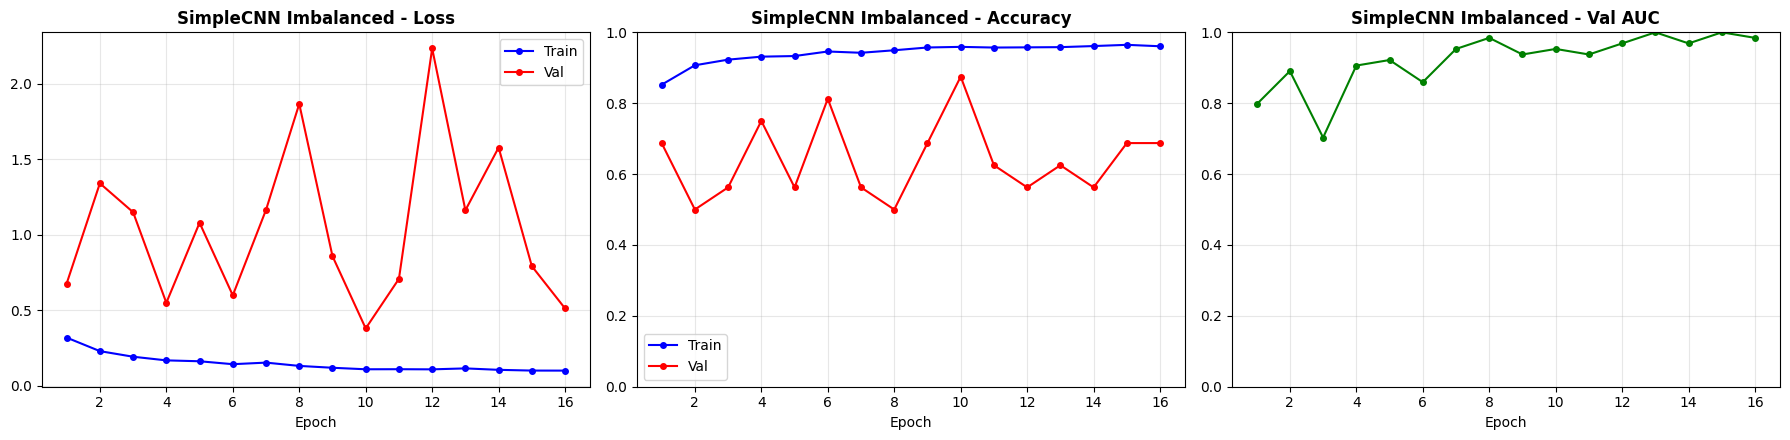

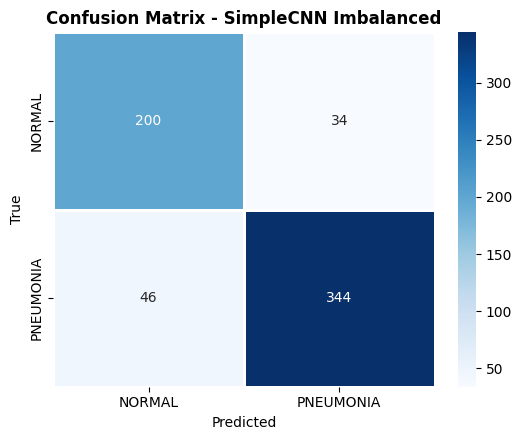

Accuracy 0.8718 | AUC-ROC 0.9254
              precision    recall  f1-score   support

      NORMAL       0.81      0.85      0.83       234
   PNEUMONIA       0.91      0.88      0.90       390

    accuracy                           0.87       624
   macro avg       0.86      0.87      0.86       624
weighted avg       0.87      0.87      0.87       624



In [11]:
# Experiment 1: SimpleCNN from scratch, imbalanced
name, arch = EXPERIMENTS[0]
model = build_model(arch); count_params(model, name)
model, hist = train_model(model, train_loader, val_loader,
                          num_epochs=20, lr=1e-3, patience=6, experiment_name=name)
plot_training_curves(hist, name)
res = evaluate_model(model, test_loader)
plot_confusion_matrix(res['confusion_matrix'], name)
print(f"Accuracy {res['accuracy']:.4f} | AUC-ROC {res['auc_roc']:.4f}")
print(classification_report(res['labels'], res['preds'], target_names=CLASS_NAMES))
all_results[name], all_histories[name] = res, hist
del model

ResNet50 Imbalanced | Total: 23,512,130 | Trainable: 23,512,130

  ResNet50 Imbalanced


Epoch [01/20]  Train L 0.2938 A 0.8819 | Val L 0.6690 A 0.6250 AUC 0.8906 | 56.7s


Epoch [02/20]  Train L 0.1747 A 0.9321 | Val L 0.8232 A 0.6250 AUC 0.7500 | 56.0s


Epoch [03/20]  Train L 0.1562 A 0.9434 | Val L 0.6072 A 0.6875 AUC 0.8125 | 56.6s


Epoch [04/20]  Train L 0.1279 A 0.9502 | Val L 1.4195 A 0.6250 AUC 0.8750 | 56.4s


...

Epoch [13/20]  Train L 0.0730 A 0.9726 | Val L 0.5610 A 0.8125 AUC 0.9219 | 56.3s


Epoch [14/20]  Train L 0.0746 A 0.9720 | Val L 0.2963 A 0.8750 AUC 0.9375 | 55.9s


Epoch [15/20]  Train L 0.0849 A 0.9720 | Val L 0.5582 A 0.7500 AUC 0.8594 | 57.9s


Epoch [16/20]  Train L 0.0592 A 0.9797 | Val L 0.3767 A 0.8125 AUC 0.9062 | 56.0s


Epoch [17/20]  Train L 0.0556 A 0.9797 | Val L 0.2834 A 0.8125 AUC 0.9219 | 57.2s
Early stopping at epoch 17


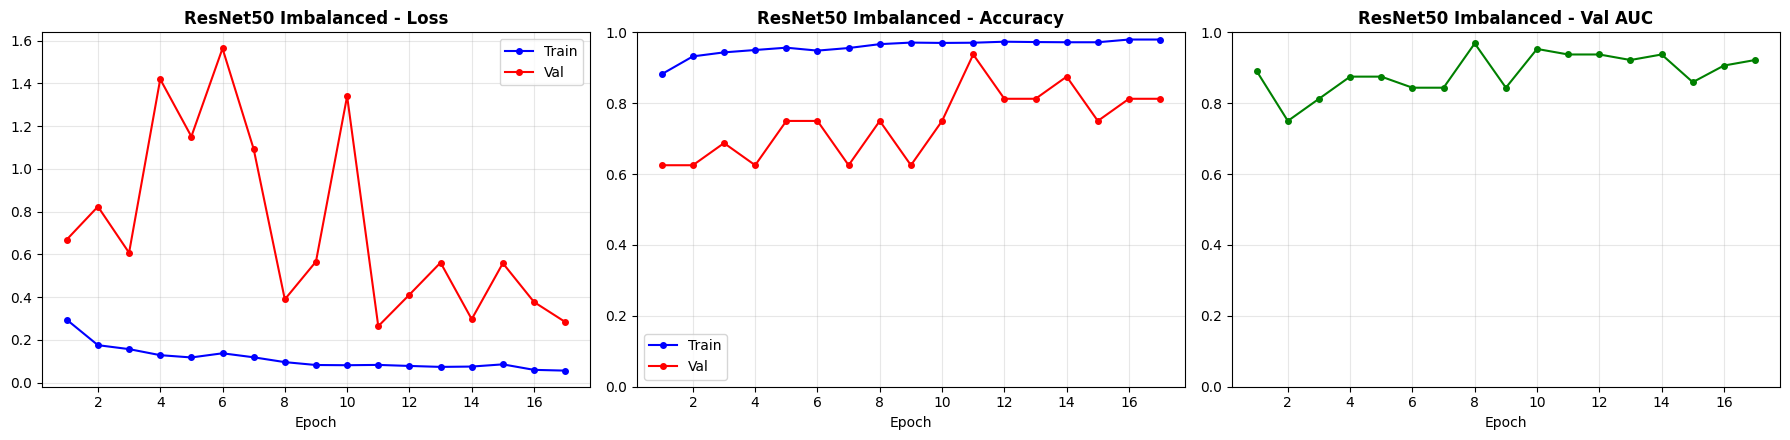

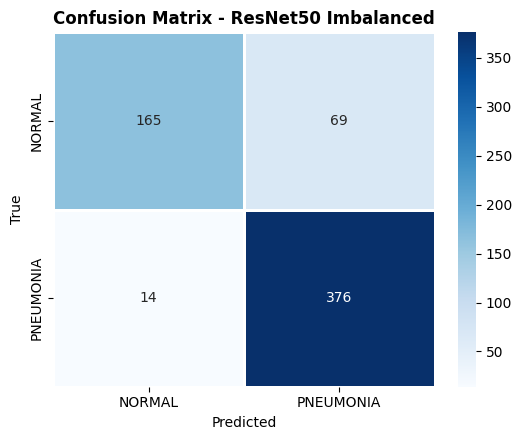

Accuracy 0.8670 | AUC-ROC 0.9480
              precision    recall  f1-score   support

      NORMAL       0.92      0.71      0.80       234
   PNEUMONIA       0.84      0.96      0.90       390

    accuracy                           0.87       624
   macro avg       0.88      0.83      0.85       624
weighted avg       0.87      0.87      0.86       624



In [12]:
# Experiment 2: ResNet50 from scratch, imbalanced
name, arch = EXPERIMENTS[1]
model = build_model(arch); count_params(model, name)
model, hist = train_model(model, train_loader, val_loader,
                          num_epochs=20, lr=1e-3, patience=6, experiment_name=name)
plot_training_curves(hist, name)
res = evaluate_model(model, test_loader)
plot_confusion_matrix(res['confusion_matrix'], name)
print(f"Accuracy {res['accuracy']:.4f} | AUC-ROC {res['auc_roc']:.4f}")
print(classification_report(res['labels'], res['preds'], target_names=CLASS_NAMES))
all_results[name], all_histories[name] = res, hist
del model

## 7. Results & Visualizations

In [13]:
# Summary table
rows = []
for n, r in all_results.items():
    rep = r['report']
    rows.append({'Model': n, 'Accuracy': f"{r['accuracy']:.4f}", 'AUC-ROC': f"{r['auc_roc']:.4f}",
                 'NORMAL recall': f"{rep['NORMAL']['recall']:.4f}",
                 'PNEUMONIA recall': f"{rep['PNEUMONIA']['recall']:.4f}",
                 'Macro-F1': f"{rep['macro avg']['f1-score']:.4f}"})
summary_df = pd.DataFrame(rows)
print('='*90); print(summary_df.to_string(index=False)); print('='*90)
print('Watch NORMAL (minority) recall — overall accuracy can look fine while this collapses.')

               Model Accuracy AUC-ROC NORMAL recall PNEUMONIA recall Macro-F1
SimpleCNN Imbalanced   0.8718  0.9254        0.8547           0.8821   0.8646
 ResNet50 Imbalanced   0.8670  0.9480        0.7051           0.9641   0.8498
Watch NORMAL (minority) recall — overall accuracy can look fine while this collapses.


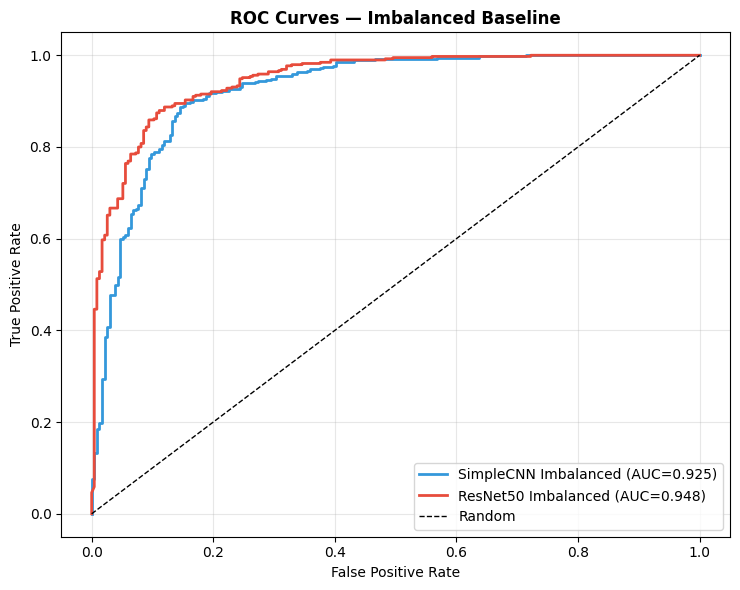

In [14]:
# ROC curves
fig, ax = plt.subplots(figsize=(7.5, 6))
for (n, r), c in zip(all_results.items(), ['#3498db', '#e74c3c']):
    fpr, tpr, _ = roc_curve(r['labels'], r['probs'])
    ax.plot(fpr, tpr, color=c, lw=2, label=f"{n} (AUC={auc(fpr, tpr):.3f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Imbalanced Baseline', fontweight='bold'); ax.legend(loc='lower right'); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig('p1_roc_curves.png', bbox_inches='tight', dpi=150); plt.show()

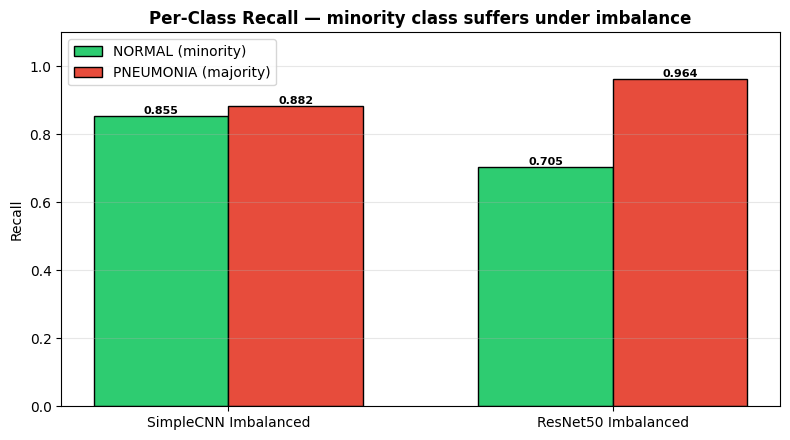

In [15]:
# Per-class recall — the key imbalance diagnostic
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(all_results)); w = 0.35
nrec = [r['report']['NORMAL']['recall']    for r in all_results.values()]
prec = [r['report']['PNEUMONIA']['recall'] for r in all_results.values()]
b1 = ax.bar(x - w/2, nrec, w, label='NORMAL (minority)', color='#2ecc71', edgecolor='black')
b2 = ax.bar(x + w/2, prec, w, label='PNEUMONIA (majority)', color='#e74c3c', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(list(all_results.keys())); ax.set_ylim([0, 1.1])
ax.set_ylabel('Recall'); ax.set_title('Per-Class Recall — minority class suffers under imbalance', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=.3)
for b in list(b1) + list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{b.get_height():.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout(); plt.savefig('p1_per_class_recall.png', bbox_inches='tight', dpi=150); plt.show()

## 8. Discussion

- **Overall accuracy is misleading.** A model that leans toward the majority class
  (PNEUMONIA) still scores high accuracy because PNEUMONIA dominates the test set.
- **NORMAL (minority) recall is the real story.** Expect it to lag PNEUMONIA recall —
  the model under-detects healthy patients (false positives for pneumonia).
- **Tiny official val set (16 images)** makes early-stopping and checkpoint selection
  noisy and unreliable.

➡️ **Part 2** fixes both problems: merge + stratified 80/10/10 re-split, and a
`WeightedRandomSampler` so each mini-batch is class-balanced. Same from-scratch models,
plus VGG16 and MobileNetV2.